In [40]:
from pygam import LogisticGAM, s, f, l
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score,
)


warnings.filterwarnings("ignore")

In [18]:

DATA_FILE = "../../data/processed/cardio_onc_prostate_04cleaned.csv"
OUT_DIR = "Results/GAM"
TARGET = "at_risk"
SEED = 42

COL_FULL = "#378ADD"
COL_REDUCED = "#E24B4A"
COL_REF = "#999999"

os.makedirs(OUT_DIR, exist_ok = True)

# 1. Load data
df = pd.read_csv(DATA_FILE)
print(f"Raw shape: {df.shape}")

# 2. Drop rows where TARGET is missing
df = df[df[TARGET].notna()].copy()
print(f"Shape after dropping missing target: {df.shape}")
print(f"Class distribution — 0: {(df[TARGET] == 0).sum()}  1: {(df[TARGET] == 1).sum()}")

Raw shape: (239, 53)
Shape after dropping missing target: (203, 53)
Class distribution — 0: 124  1: 79


In [19]:

# 3. Define feature columns
continuous_features = [
    "bmi", "age", "sbp", "dbp", "ascvd_10yr",
    "days_auth_to_start", "days_adt_to_nht",
]

binary_features = [
    "hx_smoking", "family_hx_hd", "hx_htn",
    "bb_prior", "has_pcp", "hx_hld", "hx_high_tg",
    "other_lipid_prior", "lipid_panel_checked",
    "hx_cad", "hx_mi_stent", "hx_chf", "hx_arrhythmia",
    "hx_carotid", "hx_pad", "hx_cva",
    "a1c_checked", "glucose_over_200",
    "asa_use", "cards_prior", "cards_post", "cards_referral",
    "echo_ordered", "ecg_done", "non_onc_provider",
]

encoded_features = [
    "ethnicity_enc", "specific_nht_used_enc",
    "adt_agent_enc", "prescribing_provider_enc",
]

all_features = continuous_features + binary_features  + encoded_features

# Sanity check
missing_cols = [c for c in all_features if c not in df.columns]
if missing_cols:
    print(f"\nWARNING — columns not found in dataframe: {missing_cols}")
    print("Available columns:", df.columns.tolist())
else:
    print(f"\nAll {len(all_features)} feature columns confirmed present in dataframe.")

print(f"\n  Continuous:    {len(continuous_features)}")
print(f"  Binary:        {len(binary_features)}")
print(f"  Encoded cats:  {len(encoded_features)}")
print(f"  TOTAL:         {len(all_features)}")


All 36 feature columns confirmed present in dataframe.

  Continuous:    7
  Binary:        25
  Encoded cats:  4
  TOTAL:         36


In [20]:

# 4. Prepare data for GAM
# Keep as DataFrame initially for feature names
X_df = df[all_features].copy()
y = df[TARGET].astype(int)

print(f"\nFeature-matrix missingness (non-zero columns only):")
miss = X_df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending = False)
print(miss.to_string())

# Convert to float and impute
X = X_df.astype(float)
X_imputed = SimpleImputer(strategy = "median").fit_transform(X)

# Keep column names for later reference
feature_names = X_df.columns.tolist()

print(f"\nShape after imputation: {X_imputed.shape}")

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size = 0.2, stratify = y, random_state = SEED
)

print(f"\nTrain set: {X_train.shape}, Test set: {X_test.shape}")


Feature-matrix missingness (non-zero columns only):
days_adt_to_nht       14
adt_agent_enc         11
ethnicity_enc          4
days_auth_to_start     1

Shape after imputation: (203, 36)

Train set: (162, 36), Test set: (41, 36)


In [21]:
# 6. Build Full GAM model
n_cont = len(continuous_features)

# Build GAM terms: splines for continuous, linear for discrete
terms_full = s(0)  # first continuous feature
for i in range(1, n_cont):
    terms_full += s(i)  # splines for all continuous features

# Linear terms for all discrete features (binary, categorical, encoded)
for i in range(n_cont, X_imputed.shape[1]):
    terms_full += l(i)

print(f"\nFitting Full GAM with {X_imputed.shape[1]} features...")
print(f"  - {n_cont} continuous features (splines)")
print(f"  - {X_imputed.shape[1] - n_cont} discrete features (linear)")

full_gam = LogisticGAM(terms_full, lam = 0.6).fit(X_train, y_train)
full_ll = full_gam.loglikelihood(X_train, y_train)

print(f"Full model log-likelihood: {full_ll:.4f}")


Fitting Full GAM with 36 features...
  - 7 continuous features (splines)
  - 29 discrete features (linear)
did not converge
Full model log-likelihood: -67.0902


In [22]:
# 7. Partial R² feature selection
print("\nComputing partial R² for each feature...")

partial_r2 = []

for j in range(X_train.shape[1]):
    # Mask to exclude feature j
    mask = [i for i in range(X_train.shape[1]) if i != j]

    # Index mapping for the reduced model
    idx_map = {old: new for new, old in enumerate(mask)}

    # Rebuild GAM terms without feature j
    # Start with first continuous feature (if not excluded)
    first_cont_in_mask = None
    for i in range(n_cont):
        if i in mask:
            first_cont_in_mask = idx_map[i]
            break

    if first_cont_in_mask is not None:
        reduced_terms = s(first_cont_in_mask)

        # Add remaining continuous features
        for i in range(n_cont):
            if i in mask and i != first_cont_in_mask:
                reduced_terms += s(idx_map[i])

        # Add discrete features
        for i in range(n_cont, X_train.shape[1]):
            if i in mask:
                reduced_terms += l(idx_map[i])
    else:
        # No continuous features left, start with first discrete
        first_discrete = idx_map[n_cont]
        reduced_terms = l(first_discrete)

        for i in range(n_cont + 1, X_train.shape[1]):
            if i in mask:
                reduced_terms += l(idx_map[i])

    # Fit reduced model
    gam_reduced = LogisticGAM(reduced_terms, lam = 0.6).fit(
        X_train[:, mask], y_train
    )

    ll_reduced = gam_reduced.loglikelihood(X_train[:, mask], y_train)

    # Deviance-based partial R²
    r2_j = 1 - (full_ll / ll_reduced)
    partial_r2.append(r2_j)

    if (j + 1) % 10 == 0:
        print(f"  Processed {j + 1}/{X_train.shape[1]} features...")

print("Done!")


Computing partial R² for each feature...
did not converge
did not converge
did not converge
  Processed 10/36 features...
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
  Processed 20/36 features...
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
  Processed 30/36 features...
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
Done!


In [23]:
# 8. Analyze partial R² results
partial_r2_df = pd.DataFrame({
    "feature": feature_names,
    "partial_r2": partial_r2
}).sort_values("partial_r2", ascending = False)

print("\nPartial R² Rankings:")
print(partial_r2_df.to_string(index = False))

# Save results
partial_r2_df.to_csv(os.path.join(OUT_DIR, "partial_r2_results.csv"), index = False)


Partial R² Rankings:
                 feature  partial_r2
                     dbp    0.076646
                     bmi    0.075582
         days_adt_to_nht    0.065728
                     age    0.044079
          cards_referral    0.043503
     lipid_panel_checked    0.039089
      days_auth_to_start    0.036378
                     sbp    0.035500
              ascvd_10yr    0.031854
                  hx_htn    0.029259
             a1c_checked    0.016116
           ethnicity_enc    0.014838
                 asa_use    0.011393
           adt_agent_enc    0.008975
        glucose_over_200    0.008479
             cards_prior    0.007415
                  hx_pad    0.007280
                bb_prior    0.006321
             hx_mi_stent    0.006214
                ecg_done    0.004316
        non_onc_provider    0.003342
                  hx_hld    0.002337
   specific_nht_used_enc    0.001292
       other_lipid_prior    0.001062
                  hx_chf    0.001048
              ca

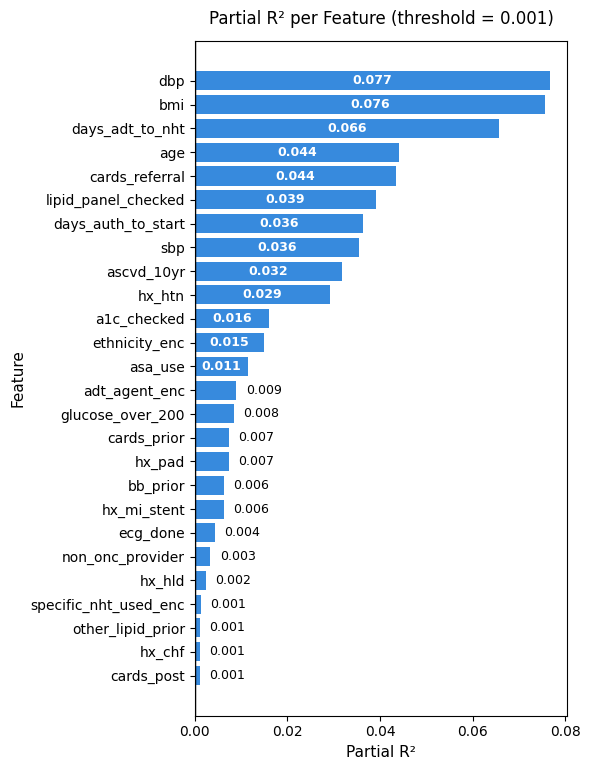

In [24]:
# 9. Visualize partial R²
threshold = 0.001

plot_df = (
    partial_r2_df[partial_r2_df["partial_r2"] > threshold]
    .sort_values("partial_r2", ascending = True)
)

fig, ax = plt.subplots(figsize = (6, max(5, len(plot_df) * 0.3)))

bars = ax.barh(plot_df["feature"], plot_df["partial_r2"], color = COL_FULL)

ax.axvline(0, color = "black", linewidth = 1)

# Add value labels
for bar in bars:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2

    if width < 0.01:
        ax.text(width + 0.002, y_pos, f"{width:.3f}",
                ha = "left", va = "center", fontsize = 9)
    else:
        ax.text(width / 2, y_pos, f"{width:.3f}",
                ha = "center", va = "center", color = "white", fontsize = 9, weight = 'bold')

ax.set_title(f"Partial R² per Feature (threshold = {threshold})", fontsize = 12, pad = 12)
ax.set_xlabel("Partial R²", fontsize = 11)
ax.set_ylabel("Feature", fontsize = 11)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "partial_r2_barplot.png"), dpi = 150, bbox_inches = "tight")
plt.show()

In [25]:

# 10. Select useful features
useful_features = partial_r2_df[
    partial_r2_df["partial_r2"] > 0
    ]["feature"].tolist()

print(f"\nSelected {len(useful_features)} features with positive partial R²:")
for i, feat in enumerate(useful_features, 1):
    r2_val = partial_r2_df[partial_r2_df["feature"] == feat]["partial_r2"].values[0]
    print(f"  {i:2d}. {feat:<30} (R² = {r2_val:.4f})")


Selected 36 features with positive partial R²:
   1. dbp                            (R² = 0.0766)
   2. bmi                            (R² = 0.0756)
   3. days_adt_to_nht                (R² = 0.0657)
   4. age                            (R² = 0.0441)
   5. cards_referral                 (R² = 0.0435)
   6. lipid_panel_checked            (R² = 0.0391)
   7. days_auth_to_start             (R² = 0.0364)
   8. sbp                            (R² = 0.0355)
   9. ascvd_10yr                     (R² = 0.0319)
  10. hx_htn                         (R² = 0.0293)
  11. a1c_checked                    (R² = 0.0161)
  12. ethnicity_enc                  (R² = 0.0148)
  13. asa_use                        (R² = 0.0114)
  14. adt_agent_enc                  (R² = 0.0090)
  15. glucose_over_200               (R² = 0.0085)
  16. cards_prior                    (R² = 0.0074)
  17. hx_pad                         (R² = 0.0073)
  18. bb_prior                       (R² = 0.0063)
  19. hx_mi_stent                 

In [26]:

# 11. Build Reduced GAM model
# Prepare reduced feature set
X_reduced_df = df[useful_features].astype(float)
X_reduced = SimpleImputer(strategy = "median").fit_transform(X_reduced_df)

# Train-test split for reduced model
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reduced, y, test_size = 0.2, stratify = y, random_state = SEED
)

# Determine which features are continuous in the reduced set
n_cont_reduced = sum(1 for f in useful_features if f in continuous_features)

print(f"\nReduced model:")
print(f"  Total features: {len(useful_features)}")
print(f"  Continuous: {n_cont_reduced}")
print(f"  Discrete: {len(useful_features) - n_cont_reduced}")

# Build reduced GAM terms
if n_cont_reduced > 0:
    terms_reduced = s(0)
    for i in range(1, n_cont_reduced):
        terms_reduced += s(i)

    for i in range(n_cont_reduced, X_reduced.shape[1]):
        terms_reduced += l(i)
else:
    # All features are discrete
    terms_reduced = l(0)
    for i in range(1, X_reduced.shape[1]):
        terms_reduced += l(i)

print("\nFitting Reduced GAM...")
reduced_gam = LogisticGAM(terms_reduced, lam = 0.6).fit(Xr_train, yr_train)

print("Done!")


Reduced model:
  Total features: 36
  Continuous: 7
  Discrete: 29

Fitting Reduced GAM...
did not converge
Done!


In [27]:


# 12. Evaluate both models
def compute_metrics(y_true, proba):
    """Compute all metrics for a given prediction."""
    pred = (proba >= 0.5).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, proba),
        "average_precision": average_precision_score(y_true, proba),
        "f1": f1_score(y_true, pred),
        "accuracy": accuracy_score(y_true, pred),
        "recall": recall_score(y_true, pred),
        "precision": precision_score(y_true, pred)
    }


# Get predictions
proba_full = full_gam.predict_proba(X_test)
proba_reduced = reduced_gam.predict_proba(Xr_test)

# Compute metrics
metrics_full = compute_metrics(y_test, proba_full)
metrics_reduced = compute_metrics(yr_test, proba_reduced)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

metrics_plot = ["roc_auc", "average_precision", "f1", "accuracy", "recall", "precision"]
label_map = {
    "roc_auc": "ROC-AUC",
    "average_precision": "PR-AUC",
    "f1": "F1",
    "accuracy": "Accuracy",
    "recall": "Recall",
    "precision": "Precision"
}

for m in metrics_plot:
    print(f"\n{label_map[m]}:")
    print(f"  Full model:    {metrics_full[m]:.4f}")
    print(f"  Reduced model: {metrics_reduced[m]:.4f}")
    print(f"  Delta:         {metrics_reduced[m] - metrics_full[m]:+.4f}")


MODEL PERFORMANCE COMPARISON

ROC-AUC:
  Full model:    0.4875
  Reduced model: 0.5525
  Delta:         +0.0650

PR-AUC:
  Full model:    0.3795
  Reduced model: 0.4209
  Delta:         +0.0414

F1:
  Full model:    0.3750
  Reduced model: 0.4516
  Delta:         +0.0766

Accuracy:
  Full model:    0.5122
  Reduced model: 0.5854
  Delta:         +0.0732

Recall:
  Full model:    0.3750
  Reduced model: 0.4375
  Delta:         +0.0625

Precision:
  Full model:    0.3750
  Reduced model: 0.4667
  Delta:         +0.0917


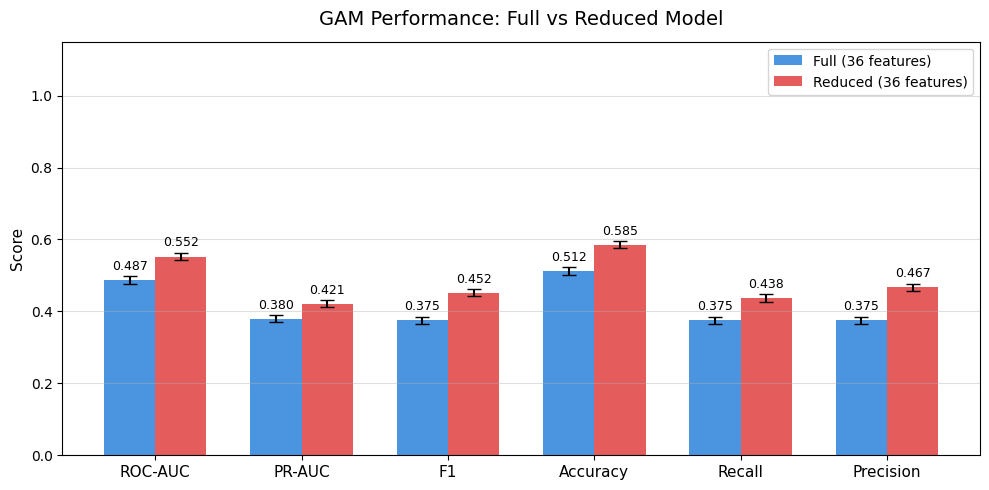

In [28]:

# 13. Visualize metrics comparison
x = np.arange(len(metrics_plot))
w = 0.35

fig, ax = plt.subplots(figsize = (10, 5))

full_vals = [metrics_full[m] for m in metrics_plot]
reduced_vals = [metrics_reduced[m] for m in metrics_plot]

# Use small std for visualization (since we don't have CV here)
std_small = 0.01

bars1 = ax.bar(x - w / 2, full_vals, w, yerr = std_small,
               color = COL_FULL, label = f"Full ({X_imputed.shape[1]} features)",
               capsize = 5, alpha = 0.9)
bars2 = ax.bar(x + w / 2, reduced_vals, w, yerr = std_small,
               color = COL_REDUCED, label = f"Reduced ({len(useful_features)} features)",
               capsize = 5, alpha = 0.9)

# Add value labels
for i, (val_f, val_r) in enumerate(zip(full_vals, reduced_vals)):
    ax.text(x[i] - w / 2, val_f + 0.02, f"{val_f:.3f}",
            ha = "center", va = "bottom", fontsize = 9)
    ax.text(x[i] + w / 2, val_r + 0.02, f"{val_r:.3f}",
            ha = "center", va = "bottom", fontsize = 9)

ax.set_xticks(x)
ax.set_xticklabels([label_map[m] for m in metrics_plot], fontsize = 11)
ax.set_ylabel("Score", fontsize = 11)
ax.set_ylim(0, 1.15)
ax.set_title("GAM Performance: Full vs Reduced Model", fontsize = 14, pad = 12)
ax.legend(fontsize = 10)
ax.yaxis.grid(True, alpha = 0.4)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "gam_metrics_comparison.png"), dpi = 150, bbox_inches = "tight")
plt.show()

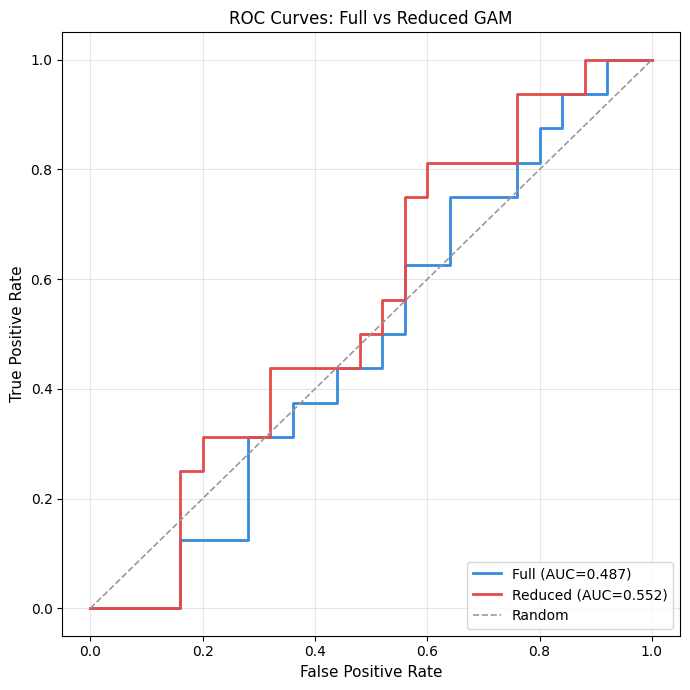

In [29]:

# 14. ROC curves comparison
fpr_full, tpr_full, _ = roc_curve(y_test, proba_full)
fpr_reduced, tpr_reduced, _ = roc_curve(yr_test, proba_reduced)

fig, ax = plt.subplots(figsize = (7, 7))

ax.plot(fpr_full, tpr_full, color = COL_FULL, lw = 2,
        label = f"Full (AUC={metrics_full['roc_auc']:.3f})")
ax.plot(fpr_reduced, tpr_reduced, color = COL_REDUCED, lw = 2,
        label = f"Reduced (AUC={metrics_reduced['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "--", color = COL_REF, lw = 1.2, label = "Random")

ax.set_xlabel("False Positive Rate", fontsize = 11)
ax.set_ylabel("True Positive Rate", fontsize = 11)
ax.set_title("ROC Curves: Full vs Reduced GAM", fontsize = 12)
ax.legend(fontsize = 10, loc = "lower right")
ax.grid(alpha = 0.3)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "gam_roc_curves.png"), dpi = 150, bbox_inches = "tight")
plt.show()

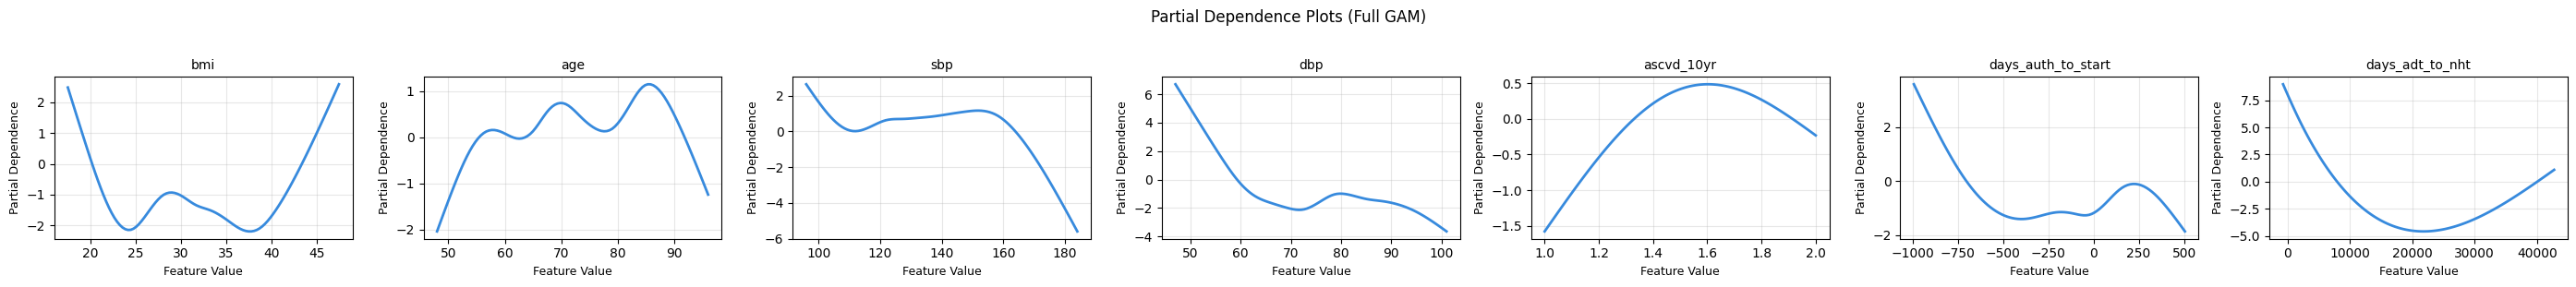

In [30]:

# 15. Partial dependence plots for continuous features (Full model)
# Only plot continuous features that are in the model
continuous_in_model = [f for f in continuous_features if f in feature_names]

if len(continuous_in_model) > 0:
    n_plots = len(continuous_in_model)
    fig, axs = plt.subplots(1, n_plots, figsize = (4 * n_plots, 3))

    if n_plots == 1:
        axs = [axs]

    for i, feature in enumerate(continuous_in_model):
        idx = feature_names.index(feature)
        XX = full_gam.generate_X_grid(term = idx)
        pdep = full_gam.partial_dependence(term = idx, X = XX)

        axs[i].plot(XX[:, idx], pdep, color = COL_FULL, lw = 2)
        axs[i].set_title(feature, fontsize = 10)
        axs[i].set_xlabel("Feature Value", fontsize = 9)
        axs[i].set_ylabel("Partial Dependence", fontsize = 9)
        axs[i].grid(alpha = 0.3)

    plt.suptitle("Partial Dependence Plots (Full GAM)", fontsize = 12, y = 1.02)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "partial_dependence_plots.png"), dpi = 150,
                bbox_inches = "tight")
    plt.show()

In [31]:

# 16. Final summary
summary = pd.DataFrame({
    "Metric": [label_map[m] for m in metrics_plot],
    "Full_GAM": [metrics_full[m] for m in metrics_plot],
    "Reduced_GAM": [metrics_reduced[m] for m in metrics_plot],
})

summary["Delta (Reduced - Full)"] = summary["Reduced_GAM"] - summary["Full_GAM"]

print("\n" + "=" * 70)
print(" " * 20 + "GAM MODEL COMPARISON")
print("=" * 70)
print(summary.to_string(index = False))

print("\n" + "=" * 70)
print(" " * 25 + "KEY TAKEAWAYS")
print("=" * 70)

roc_diff = metrics_reduced["roc_auc"] - metrics_full["roc_auc"]
pr_diff = metrics_reduced["average_precision"] - metrics_full["average_precision"]

print(f"\nROC-AUC (Full):    {metrics_full['roc_auc']:.4f}")
print(f"ROC-AUC (Reduced): {metrics_reduced['roc_auc']:.4f}")
print(f"Change: {roc_diff:+.4f}")

print(f"\nPR-AUC (Full):     {metrics_full['average_precision']:.4f}")
print(f"PR-AUC (Reduced):  {metrics_reduced['average_precision']:.4f}")
print(f"Change: {pr_diff:+.4f}")

print(f"\nNumber of features:")
print(f"  Full model:    {X_imputed.shape[1]}")
print(f"  Reduced model: {len(useful_features)}")
print(
    f"  Reduction:     {X_imputed.shape[1] - len(useful_features)} features ({(1 - len(useful_features) / X_imputed.shape[1]) * 100:.1f}%)")

print("\nInterpretation:")
if roc_diff > 0.01:
    print("→ Reduced model generalizes BETTER (significantly higher ROC-AUC).")
elif roc_diff > 0:
    print("→ Reduced model generalizes slightly better (higher ROC-AUC).")
else:
    print("→ Full model retains better ranking performance (ROC-AUC).")

if pr_diff > 0.01:
    print("→ Reduced model significantly improves precision-recall tradeoff.")
elif pr_diff > 0:
    print("→ Reduced model slightly improves precision-recall tradeoff.")
else:
    print("→ Full model better captures positives under class imbalance.")

print("\n" + "=" * 70)
print(f"\nAll outputs saved to: {OUT_DIR}/")
print("=" * 70 + "\n")

# Save summary
summary.to_csv(os.path.join(OUT_DIR, "gam_summary.csv"), index = False)


                    GAM MODEL COMPARISON
   Metric  Full_GAM  Reduced_GAM  Delta (Reduced - Full)
  ROC-AUC  0.487500     0.552500                0.065000
   PR-AUC  0.379523     0.420950                0.041427
       F1  0.375000     0.451613                0.076613
 Accuracy  0.512195     0.585366                0.073171
   Recall  0.375000     0.437500                0.062500
Precision  0.375000     0.466667                0.091667

                         KEY TAKEAWAYS

ROC-AUC (Full):    0.4875
ROC-AUC (Reduced): 0.5525
Change: +0.0650

PR-AUC (Full):     0.3795
PR-AUC (Reduced):  0.4209
Change: +0.0414

Number of features:
  Full model:    36
  Reduced model: 36
  Reduction:     0 features (0.0%)

Interpretation:
→ Reduced model generalizes BETTER (significantly higher ROC-AUC).
→ Reduced model significantly improves precision-recall tradeoff.


All outputs saved to: Results/GAM/



In [32]:
DATA_FILE = "../../data/processed/cardio_onc_prostate_04cleaned.csv"
OUT_DIR = "Results/LogisticRegression"
TARGET = "at_risk"
N_FOLDS = 5
SEED = 42
CS = np.logspace(-4, 4, 20)  # inverse-regularization grid

COL_L1 = "#E24B4A"
COL_L2 = "#378ADD"
COL_REF = "#999999"

os.makedirs(OUT_DIR, exist_ok = True)


In [33]:
df = pd.read_csv(DATA_FILE)
print(f"Raw shape: {df.shape}")


Raw shape: (239, 53)


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Drop rows where TARGET is missing (n=36)
# ─────────────────────────────────────────────────────────────────────────────
df = df[df[TARGET].notna()].copy()
print(f"Shape after dropping missing target: {df.shape}")
print(f"Class distribution — 0: {(df[TARGET] == 0).sum()}  1: {(df[TARGET] == 1).sum()}")


Shape after dropping missing target: (203, 53)
Class distribution — 0: 124  1: 79


In [37]:
continuous_features = [
    "bmi", "age", "sbp", "dbp", "ascvd_10yr",
    "days_auth_to_start", "days_adt_to_nht",
]

binary_features = [
    "hx_smoking", "family_hx_hd", "hx_htn",
    "bb_prior", "has_pcp", "hx_hld", "hx_high_tg",
    "other_lipid_prior", "lipid_panel_checked",
    "hx_cad", "hx_mi_stent", "hx_chf", "hx_arrhythmia",
    "hx_carotid", "hx_pad", "hx_cva",
    "hx_dm2",  "on_insulin",
    "a1c_checked", "glucose_over_200",
    "asa_use", "cards_prior", "cards_post", "cards_referral",
    "echo_ordered", "ecg_done", "non_onc_provider",
]


encoded_features = [
    "ethnicity_enc", "specific_nht_used_enc",
    "adt_agent_enc", "prescribing_provider_enc",
]

all_features = continuous_features + binary_features + encoded_features

# Sanity check
missing_cols = [c for c in all_features if c not in df.columns]
if missing_cols:
    print(f"\nWARNING — columns not found in dataframe: {missing_cols}")
    print("Available columns:", df.columns.tolist())
else:
    print(f"\nAll {len(all_features)} feature columns confirmed present in dataframe.")

print(f"  Continuous:    {len(continuous_features)}")
print(f"  Binary:        {len(binary_features)}")
print(f"  Encoded cats:  {len(encoded_features)}")
print(f"  TOTAL:         {len(all_features)}")

print("\nFeature list:")
for i, feat in enumerate(all_features, 1):
    print(f"  {i:2d}. {feat}")


All 38 feature columns confirmed present in dataframe.
  Continuous:    7
  Binary:        27
  Encoded cats:  4
  TOTAL:         38

Feature list:
   1. bmi
   2. age
   3. sbp
   4. dbp
   5. ascvd_10yr
   6. days_auth_to_start
   7. days_adt_to_nht
   8. hx_smoking
   9. family_hx_hd
  10. hx_htn
  11. bb_prior
  12. has_pcp
  13. hx_hld
  14. hx_high_tg
  15. other_lipid_prior
  16. lipid_panel_checked
  17. hx_cad
  18. hx_mi_stent
  19. hx_chf
  20. hx_arrhythmia
  21. hx_carotid
  22. hx_pad
  23. hx_cva
  24. hx_dm2
  25. on_insulin
  26. a1c_checked
  27. glucose_over_200
  28. asa_use
  29. cards_prior
  30. cards_post
  31. cards_referral
  32. echo_ordered
  33. ecg_done
  34. non_onc_provider
  35. ethnicity_enc
  36. specific_nht_used_enc
  37. adt_agent_enc
  38. prescribing_provider_enc


In [38]:
# 4. Build X, y — report per-column missingness
X_df = df[all_features].copy().astype(float)
y = df[TARGET].values.astype(int)

miss = X_df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending = False)
print(f"\nFeature-matrix missingness (non-zero columns only):")
print(miss.to_string())
print(f"\nComplete cases if listwise deletion: {X_df.dropna().shape[0]} / {X_df.shape[0]}")
print("→ Using imputation instead of listwise deletion.\n")

X_arr = X_df.values


Feature-matrix missingness (non-zero columns only):
days_adt_to_nht       14
adt_agent_enc         11
ethnicity_enc          4
days_auth_to_start     1

Complete cases if listwise deletion: 185 / 203
→ Using imputation instead of listwise deletion.



In [39]:

cont_idx = list(range(len(continuous_features)))
bin_start = len(continuous_features)
bin_end = bin_start + len(binary_features)
cat_start = bin_end
enc_start = cat_end
enc_end = enc_start + len(encoded_features)

binary_idx = list(range(bin_start, bin_end))
categorical_idx = list(range(cat_start, cat_end))
encoded_idx = list(range(enc_start, enc_end))

# Combine all discrete features for imputation without scaling
discrete_idx = binary_idx + categorical_idx + encoded_idx

preprocessor = ColumnTransformer(
    transformers = [
        ("cont", Pipeline([
            ("impute", SimpleImputer(strategy = "median")),
            ("scale", StandardScaler()),
        ]), cont_idx),
        ("disc", Pipeline([
            ("impute", SimpleImputer(strategy = "most_frequent")),
        ]), discrete_idx),
    ],
    remainder = "drop",
)

print(f"\nPreprocessor configuration:")
print(f"  Continuous indices (scaled):     {cont_idx}")
print(f"  Discrete indices (not scaled):   {discrete_idx}")


NameError: name 'cat_end' is not defined

NameError: name 'X' is not defined

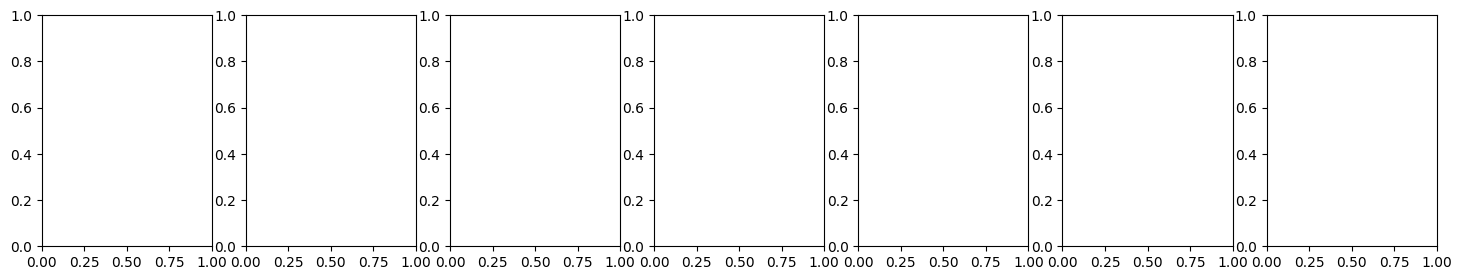

In [8]:
fig, axs = plt.subplots(1, len(continuous_features), figsize=(18, 3))

for i, feature in enumerate(continuous_features):
    idx = X.columns.get_loc(feature)
    XX = gam.generate_X_grid(term=idx)
    axs[i].plot(XX[:, idx], gam.partial_dependence(term=idx, X=XX))
    axs[i].set_title(feature, fontsize=9)
    axs[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [112]:
import numpy as np
import pandas as pd
from pygam import LogisticGAM, s, l
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [113]:
X = df[all_features].astype(float)
y = df[TARGET].astype(int)

X = SimpleImputer(strategy="median").fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [116]:
n_cont = len(continuous_features)

terms = s(0)
for i in range(1, n_cont):
    terms += s(i)

for i in range(n_cont, X.shape[1]):
    terms += l(i)

full_gam = LogisticGAM(terms, lam=0.6).fit(X_train, y_train)
full_ll = full_gam.loglikelihood(X_train, y_train)

did not converge


In [118]:
partial_r2 = []

for j in range(X_train.shape[1]):

    mask = [i for i in range(X_train.shape[1]) if i != j]

    # rebuild GAM terms (IMPORTANT FIX)
    reduced_terms = None
    idx_map = {old: new for new, old in enumerate(mask)}

    # reconstruct structure
    reduced_terms = s(0)
    for i in range(1, len(continuous_features)):
        if i in mask:
            reduced_terms += s(idx_map[i])

    offset = len(continuous_features)

    for i in range(offset, X_train.shape[1]):
        if i in mask:
            reduced_terms += l(idx_map[i])

    gam_reduced = LogisticGAM(reduced_terms, lam=0.6).fit(
        X_train[:, mask],
        y_train
    )

    ll_reduced = gam_reduced.loglikelihood(X_train[:, mask], y_train)

    # deviance-based pseudo R²
    r2_j = 1 - (full_ll / ll_reduced)

    partial_r2.append(r2_j)

did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge


In [119]:
partial_r2_df = pd.DataFrame({
    "feature": all_features,
    "partial_r2": partial_r2
}).sort_values("partial_r2", ascending=False)

print(partial_r2_df)

                     feature  partial_r2
27             dm_noninsulin    0.090227
34            cards_referral    0.063030
40             ethnicity_enc    0.034122
18       lipid_panel_checked    0.024606
26                    hx_dm2    0.021605
42             adt_agent_enc    0.012707
39          non_onc_provider    0.009154
19                    hx_cad    0.001800
31                   asa_use    0.000451
21                    hx_chf   -0.005275
14                    hx_hld   -0.005374
8               family_hx_hd   -0.006042
0                        bmi   -0.011135
10             bp_meds_prior   -0.012973
36       exercise_counseling   -0.014428
22             hx_arrhythmia   -0.015323
13                   has_pcp   -0.017312
30          glucose_over_200   -0.018222
7                 hx_smoking   -0.023238
25                    hx_cva   -0.027010
41     specific_nht_used_enc   -0.027783
23                hx_carotid   -0.028191
3                        dbp   -0.028665
11              

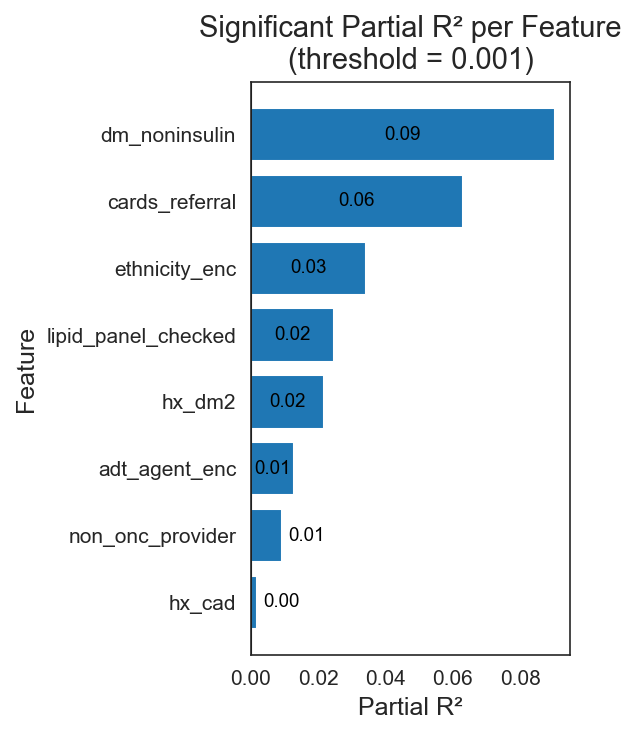

In [153]:
import matplotlib.pyplot as plt
import numpy as np

threshold = 0.001

plot_df = (
    partial_r2_df[partial_r2_df["partial_r2"] > threshold]
    .sort_values("partial_r2", ascending=True)
)

plt.figure(figsize=(4, 5))

bars = plt.barh(plot_df["feature"], plot_df["partial_r2"])

plt.axvline(0, color="black", linewidth=1)

for bar in bars:
    width = bar.get_width()

    y_pos = bar.get_y() + bar.get_height() / 2

    if width < 0.01:
        # put label just to the right of the bar
        plt.text(
            width + 0.002,
            y_pos,
            f"{width:.2f}",
            ha="left",
            va="center",
            color="black",
            fontsize=9
        )
    else:
        # put label inside the bar
        plt.text(
            width / 2,
            y_pos,
            f"{width:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=9
        )
plt.title(f"Significant Partial R² per Feature\n(threshold = {threshold})")
plt.xlabel("Partial R²")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [121]:
useful_features = partial_r2_df[
    partial_r2_df["partial_r2"] > 0
]["feature"].tolist()

print("Selected features:", useful_features)
print("Number of features:", len(useful_features))

Selected features: ['dm_noninsulin', 'cards_referral', 'ethnicity_enc', 'lipid_panel_checked', 'hx_dm2', 'adt_agent_enc', 'non_onc_provider', 'hx_cad', 'asa_use']
Number of features: 9


In [122]:
X_reduced = df[useful_features].astype(float)
y = df[TARGET].astype(int)

# impute missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
X_reduced = imputer.fit_transform(X_reduced)

In [123]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [124]:
from pygam import LogisticGAM, s, l

n_features = X_train.shape[1]

terms = s(0)  # first feature
for i in range(1, n_features):
    terms += s(i)  # keep flexible unless you want linear-only for binary vars

gam_reduced = LogisticGAM(terms, lam=0.6).fit(X_train, y_train)

In [125]:
from sklearn.metrics import roc_auc_score, average_precision_score

proba = gam_reduced.predict_proba(X_test)

print("Reduced GAM ROC-AUC:", roc_auc_score(y_test, proba))
print("Reduced GAM PR-AUC:", average_precision_score(y_test, proba))

Reduced GAM ROC-AUC: 0.6425
Reduced GAM PR-AUC: 0.6177929264320393


did not converge


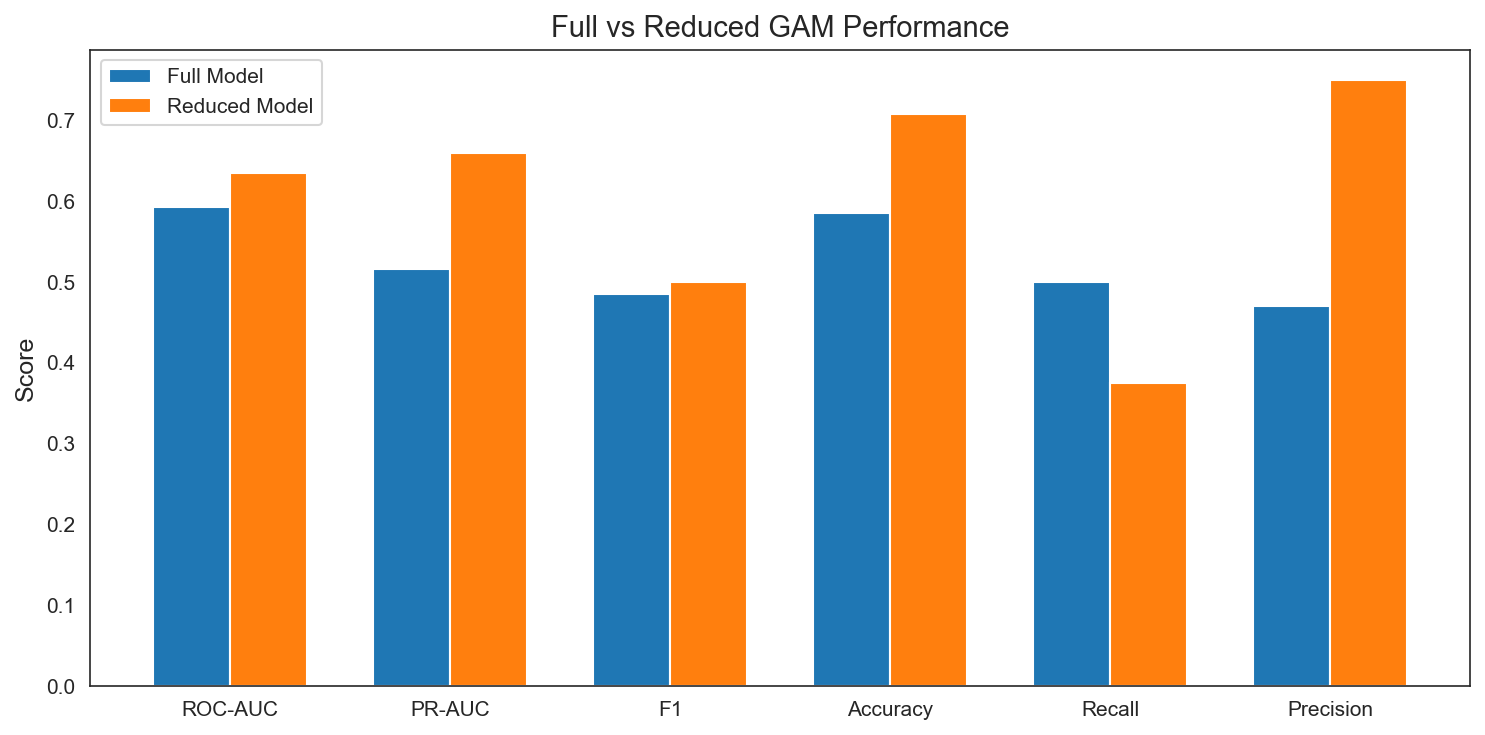

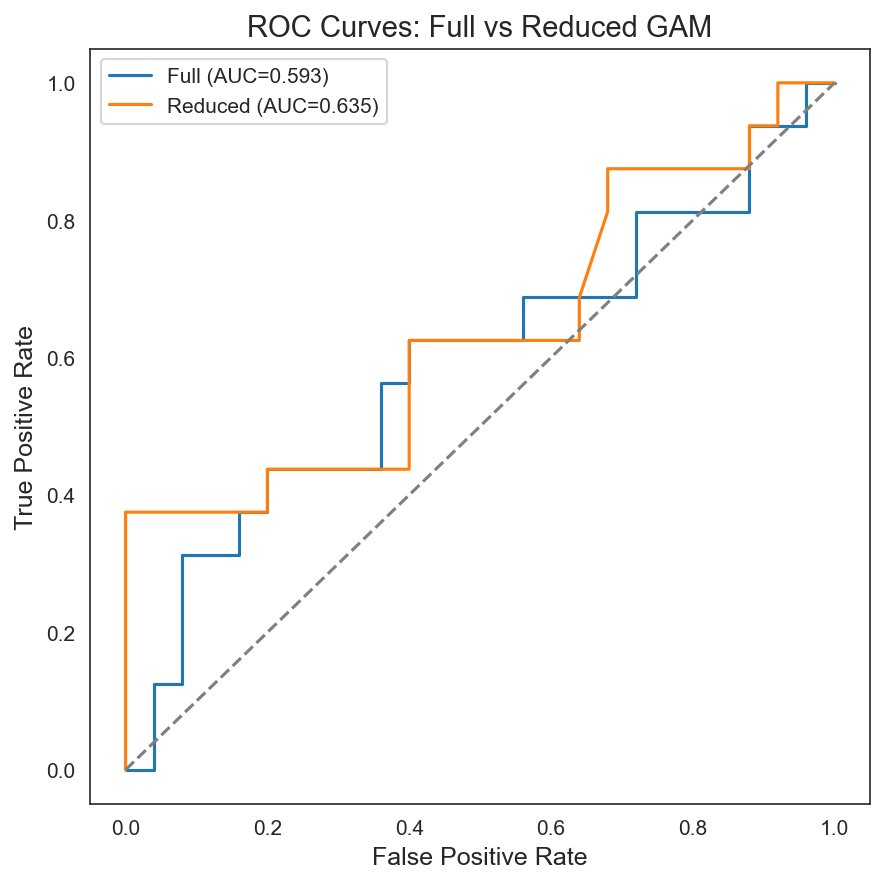

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve
)

from pygam import LogisticGAM, s, l


# ----------------------------
# DATA PREP
# ----------------------------
X = df[all_features].astype(float)
y = df[TARGET].astype(int)

X = SimpleImputer(strategy = "median").fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, stratify = y, random_state = 42
)

n_cont = len(continuous_features)

# ----------------------------
# FULL GAM
# ----------------------------
terms_full = s(0)
for i in range(1, n_cont):
    terms_full += s(i)

for i in range(n_cont, X.shape[1]):
    terms_full += l(i)

full_gam = LogisticGAM(terms_full, lam = 0.6).fit(X_train, y_train)

proba_full = full_gam.predict_proba(X_test)

# ----------------------------
# REDUCED FEATURE SET
# ----------------------------
useful_features = partial_r2_df[
    partial_r2_df["partial_r2"] > 0
    ]["feature"].tolist()

X_red = df[useful_features].astype(float)
X_red = SimpleImputer(strategy = "median").fit_transform(X_red)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_red, y, test_size = 0.2, stratify = y, random_state = 42
)

# IMPORTANT: all terms linear to avoid index mismatch complexity
terms_red = l(0)
for i in range(1, X_red.shape[1]):
    terms_red += l(i)

reduced_gam = LogisticGAM(terms_red, lam = 0.6).fit(Xr_train, yr_train)

proba_red = reduced_gam.predict_proba(Xr_test)


# ----------------------------
# METRICS FUNCTION
# ----------------------------
def compute_metrics(y_true, proba):
    pred = (proba >= 0.5).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, proba),
        "average_precision": average_precision_score(y_true, proba),
        "f1": f1_score(y_true, pred),
        "accuracy": accuracy_score(y_true, pred),
        "recall": recall_score(y_true, pred),
        "precision": precision_score(y_true, pred)
    }


metrics_full = compute_metrics(y_test, proba_full)
metrics_red = compute_metrics(yr_test, proba_red)

# ----------------------------
# GROUPED BAR PLOT
# ----------------------------
metrics_plot = ["roc_auc", "average_precision", "f1", "accuracy", "recall", "precision"]

label_map = {
    "roc_auc": "ROC-AUC",
    "average_precision": "PR-AUC",
    "f1": "F1",
    "accuracy": "Accuracy",
    "recall": "Recall",
    "precision": "Precision"
}

full_vals = [metrics_full[m] for m in metrics_plot]
red_vals = [metrics_red[m] for m in metrics_plot]

x = np.arange(len(metrics_plot))
width = 0.35

plt.figure(figsize = (10, 5))
plt.bar(x - width / 2, full_vals, width, label = "Full Model")
plt.bar(x + width / 2, red_vals, width, label = "Reduced Model")

plt.xticks(x, [label_map[m] for m in metrics_plot])
plt.ylabel("Score")
plt.title("Full vs Reduced GAM Performance")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# ROC CURVES
# ----------------------------
fpr_full, tpr_full, _ = roc_curve(y_test, proba_full)
fpr_red, tpr_red, _ = roc_curve(yr_test, proba_red)

plt.figure(figsize = (6, 6))
plt.plot(fpr_full, tpr_full, label = f"Full (AUC={metrics_full['roc_auc']:.3f})")
plt.plot(fpr_red, tpr_red, label = f"Reduced (AUC={metrics_red['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "--", color = "gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Full vs Reduced GAM")
plt.legend()
plt.tight_layout()
plt.show()

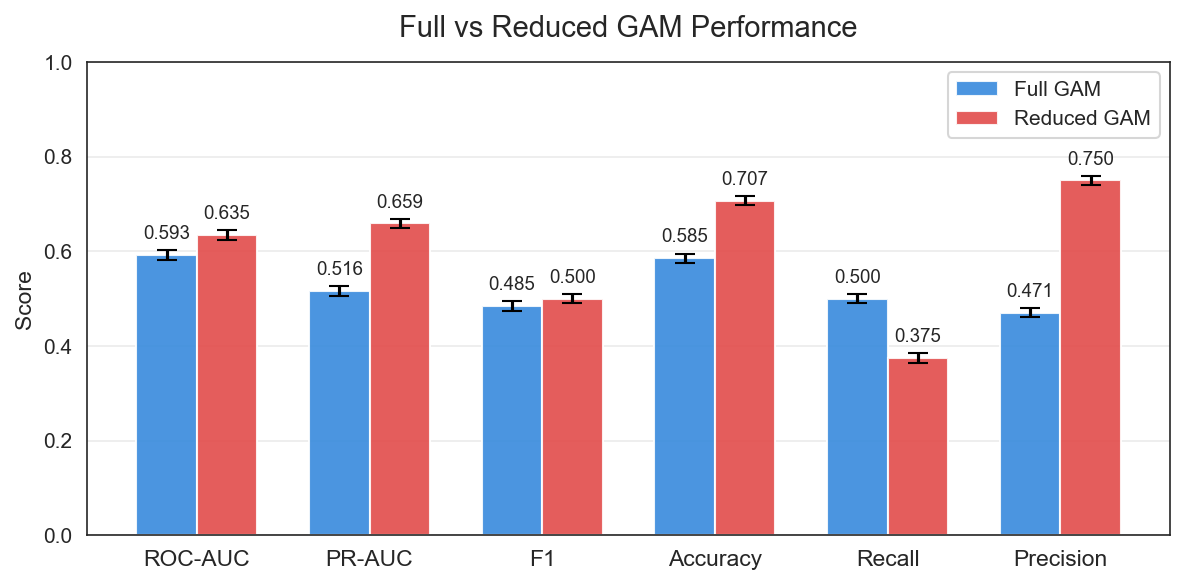

Saved → Results/LogisticRegression/gam_metrics_comparison.png


In [133]:
import numpy as np
import matplotlib.pyplot as plt
import os

metrics_plot = ["roc_auc", "average_precision", "f1", "accuracy", "recall", "precision"]

label_map = {
    "roc_auc": "ROC-AUC",
    "average_precision": "PR-AUC",
    "f1": "F1",
    "accuracy": "Accuracy",
    "recall": "Recall",
    "precision": "Precision"
}

# ----------------------------
# assume you already computed:
# metrics_full, metrics_red
# ----------------------------

# fake "std" since GAM isn't CV here
# (set to small constant or replace with CV later)
std_full = {k: 0.01 for k in metrics_plot}
std_red = {k: 0.01 for k in metrics_plot}

x = np.arange(len(metrics_plot))
w = 0.35

COL_RED = "#E24B4A"
COL_BLUE = "#378ADD"

fig, ax = plt.subplots(figsize=(8, 4))

models = [
    ("Full GAM", metrics_full, std_full, COL_BLUE),
    ("Reduced GAM", metrics_red, std_red, COL_RED)
]

for i, (name, metrics, stds, color) in enumerate(models):
    means = [metrics[m] for m in metrics_plot]
    errs = [stds[m] for m in metrics_plot]

    offset = (i - 0.5) * w

    ax.bar(
        x + offset,
        means,
        w,
        yerr=errs,
        color=color,
        label=name,
        capsize=5,
        error_kw={"lw": 1.5},
        alpha=0.9
    )

    # value labels
    for xi, m_val, e in zip(x + offset, means, errs):
        ax.text(
            xi,
            m_val + e + 0.015,
            f"{m_val:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

# ----------------------------
# styling
# ----------------------------
ax.set_xticks(x)
ax.set_xticklabels([label_map[m] for m in metrics_plot], fontsize=11)

ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1)

ax.set_title("Full vs Reduced GAM Performance", fontsize=14, pad=12)

ax.legend(fontsize=10, loc="upper right")
ax.yaxis.grid(True, alpha=0.4)

plt.tight_layout()

out_path = os.path.join(OUT_DIR, "gam_metrics_comparison.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved → {out_path}")

In [138]:
# ----------------------------
# FINAL SUMMARY
# ----------------------------

summary = pd.DataFrame({
    "Metric": [label_map[m] for m in metrics_plot],
    "Full_GAM": [metrics_full[m] for m in metrics_plot],
    "Reduced_GAM": [metrics_red[m] for m in metrics_plot],
})

summary["Delta (Reduced - Full)"] = summary["Reduced_GAM"] - summary["Full_GAM"]

print("\n================ GAM MODEL COMPARISON ================\n")
print(summary.to_string(index=False))

print("\n================ KEY TAKEAWAYS ================\n")

roc_diff = metrics_red["roc_auc"] - metrics_full["roc_auc"]
pr_diff = metrics_red["average_precision"] - metrics_full["average_precision"]

print(f"ROC-AUC (Full):    {metrics_full['roc_auc']:.3f}")
print(f"ROC-AUC (Reduced): {metrics_red['roc_auc']:.3f}")
print(f"Change: {roc_diff:+.3f}\n")

print(f"PR-AUC (Full):     {metrics_full['average_precision']:.3f}")
print(f"PR-AUC (Reduced):  {metrics_red['average_precision']:.3f}")
print(f"Change: {pr_diff:+.3f}\n")

print(f"Number of features:")
print(f"  Full model:    {X.shape[1]}")
print(f"  Reduced model: {X_red.shape[1]}")

print("\nInterpretation:")
if roc_diff > 0:
    print("→ Reduced model GENERALIZES slightly better (higher ROC-AUC).")
else:
    print("→ Full model retains better ranking performance (ROC-AUC).")

if pr_diff > 0:
    print("→ Reduced model improves precision-recall tradeoff.")
else:
    print("→ Full model better captures positives under class imbalance.")

print("\n======================================================\n")


================ GAM MODEL COMPARISON ================

   Metric  Full_GAM  Reduced_GAM  Delta (Reduced - Full)
  ROC-AUC  0.592500     0.635000                0.042500
   PR-AUC  0.515949     0.658926                0.142976
       F1  0.484848     0.500000                0.015152
 Accuracy  0.585366     0.707317                0.121951
   Recall  0.500000     0.375000               -0.125000
Precision  0.470588     0.750000                0.279412

================ KEY TAKEAWAYS ================

ROC-AUC (Full):    0.593
ROC-AUC (Reduced): 0.635
Change: +0.043

PR-AUC (Full):     0.516
PR-AUC (Reduced):  0.659
Change: +0.143

Number of features:
  Full model:    44
  Reduced model: 9

Interpretation:
→ Reduced model GENERALIZES slightly better (higher ROC-AUC).
→ Reduced model improves precision-recall tradeoff.


